<a href="https://colab.research.google.com/github/iagooleite/Calculo-Numerico/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade 2 - Cálculo Númerico**

Iago da Silva Leite | RA: 185228


---



## **Código fornecido no PDF**

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


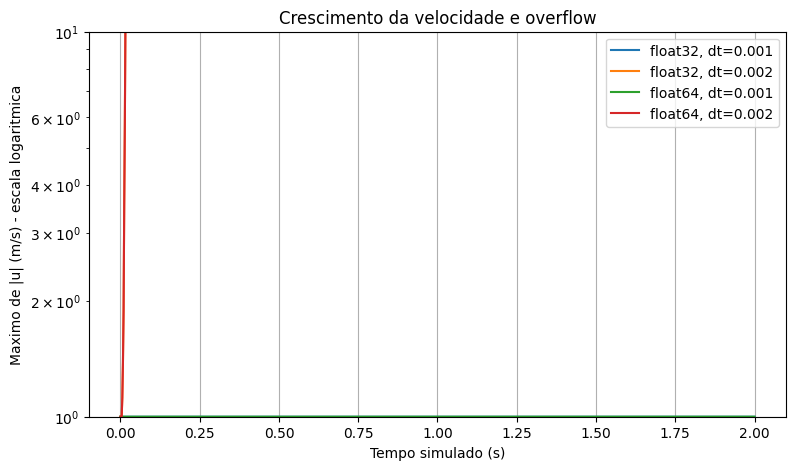

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

## **Código para as questões 1 e 2**

In [ ]:
import numpy as np
import pandas as pd

# Parâmetros base
H = 0.01
nu = 1e-4
pontos = 21

# Atividade 1
dy = H / (pontos - 1)
dt_max = (dy**2) / (2 * nu)

print(f"--- Atividade 1 ---")
print(f"Espaçamento dy: {dy:.4f} m")
print(f"Limite dt_max (teórico): {dt_max:.5f} s\n")

# Atividade 2
print(f"--- Atividade 2: Tabela de Testes ---")
resultados_lista = []

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        # Executa a simulação base
        res = simular(dt, tipo)

        # Coleta os dados para a tabela
        r_val = res["r"]
        estabilidade = "Estável" if r_val <= 0.5 else "Instável"
        falhou = "Sim" if res["falha"] is not None else "Não"
        passo_falha = res["falha"] if res["falha"] is not None else "-"

        resultados_lista.append({
            "Tipo Numérico": tipo.__name__,
            "Passo (dt)": dt,
            "Valor de r": round(r_val, 4),
            "Status Teórico": estabilidade,
            "Overflow?": falhou,
            "Iteração da Falha": passo_falha
        })

# Exibe os resultados
df_resultados = pd.DataFrame(resultados_lista)
display(df_resultados)

--- Atividade 1 ---
Espaçamento dy: 0.0005 m
Limite dt_max (teórico): 0.00125 s

--- Atividade 2: Tabela de Testes ---
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


,Tipo Numérico,Passo (dt),Valor de r,Status Teórico,Overflow?,Iteração da Falha
0,float32,0.001,0.4,Estável,Não,-
1,float32,0.002,0.8,Instável,Sim,121
2,float64,0.001,0.4,Estável,Não,-
3,float64,0.002,0.8,Instável,Sim,917


## **Código para a questão 5**

In [ ]:
print("--- Atividade 5: Refinamento da Malha ---")
pontos_novo = 41
dy_novo = H / (pontos_novo - 1)
dt_max_novo = (dy_novo**2) / (2 * nu)

print(f"Novo espaçamento (dy): {dy_novo:.5f} m")
print(f"Novo limite de estabilidade (dt_max): {dt_max_novo:.7f} s\n")

# Teste com o dt original (agora deve ser instável devido à nova malha)
print("Executando com pontos=41 e dt=0.001:")
res_ref_instavel = simular(dt=0.001, tipo=np.float64, pontos=41)

# Escolhendo um passo de tempo seguro (abaixo do novo dt_max)
dt_seguro = 0.0003
print(f"\nExecutando com passo de tempo seguro (dt={dt_seguro}):")
res_ref_estavel = simular(dt=dt_seguro, tipo=np.float64, passos=3000, pontos=41)

--- Atividade 5: Refinamento da Malha ---
Novo espaçamento (dy): 0.00025 m
Novo limite de estabilidade (dt_max): 0.0003125 s

Executando com pontos=41 e dt=0.001:
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract

Executando com passo de tempo seguro (dt=0.0003):
dt=0.0003, float64: 3000 passos sem overflow.


## **Código para a questão 6**

--- Atividade 6: Perfil de Velocidade ---
Executando simulação longa para tender ao regime estacionário...
dt=0.001, float64: 5000 passos sem overflow.
Diferença máxima entre as curvas (E_infinito) = 3.441691e-15 m/s


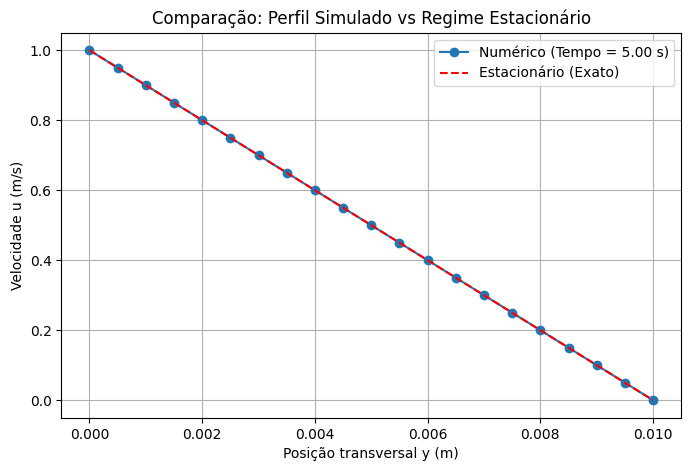

In [ ]:
import matplotlib.pyplot as plt

print("--- Atividade 6: Perfil de Velocidade ---")

U = 1.0
passos_longo = 5000
dt_estavel = 0.001

# Rodando uma simulação estável bem longa para tentar alcançar o regime estacionário
print("Executando simulação longa para tender ao regime estacionário...")
res_longo = simular(dt=dt_estavel, tipo=np.float64, passos=passos_longo, pontos=21)

y_vals = res_longo["y"]
u_simulado = res_longo["u"]

# Calcula a solução estacionária analítica
u_estacionario = U * (1 - (y_vals / H))

# Calcula a Diferença Máxima (E_infinito)
diferenca = np.abs(u_simulado - u_estacionario)
E_inf = np.max(diferenca)

print(f"Diferença máxima entre as curvas (E_infinito) = {E_inf:.6e} m/s")

# Criação do Gráfico Comparativo
plt.figure(figsize=(8, 5))
plt.plot(y_vals, u_simulado, 'o-', label=f'Numérico (Tempo = {passos_longo*dt_estavel:.2f} s)')
plt.plot(y_vals, u_estacionario, 'r--', label='Estacionário (Exato)')
plt.xlabel('Posição transversal y (m)')
plt.ylabel('Velocidade u (m/s)')
plt.title('Comparação: Perfil Simulado vs Regime Estacionário')
plt.grid(True)
plt.legend()
plt.show()

## **Respostas Teóricas**


---



## **Questão 1**

Para dt = 0,001s e r = 0,4: estável.

Para dt = 0,002s e r = 0,8: instável.

dy = 0,0005

dtmax = 0,00125

## **Questão 3**

O crescimento observado no caso instável apresenta velocidades muito superiores a 1m/s. Logo, como explicado no arquivo, essão soluções estão incorretas e não representam o comportamento físico esperado.

## **Questão 4**

A mudança de de float32 para float64 não elimina a instabilidade. A instabilidade é uma falha matemática do método quando r > 0,5, independentemente da precisão do computador. O que muda é que o float64 consegue representar valores muito maiores que o float32. Dessa forma, o erro matemático cresce exponencialmente em ambos, mas leva muito mais passos para que a velocidade no float64 atinja seu limite máximo e cause "overflow".

## **Questão 5**

O resultado será instável. Como a malha ficou menor, o antigo passo de tempo agora é grande demais para a restrição de estabilidade.

## **Questão 6**

Sim, o tempo simulado foi longo o suficiente para o fluido sair do regime transiente e atingir o estado estacionário.

## **Questão 7 - Conclusão**

A relação entre eles é que o refinamento da malha exige uma grande redução no passo de tempo (dt) para garantir que r <= 0,5. Se a malha for refinada sem reduzir o passo de tempo, o método sofre de instabilidade, fazendo com que pequenas variações e erros comecem a oscilar e crescer fora de controle. Essa instabilidade continua crescendo até ultrapassar a capacidade da variável no computador, gerando o overflow. A alteração que corrigiu a causa da falha na simulação foi escolher sempre um dt que garanta r <= 0,5.